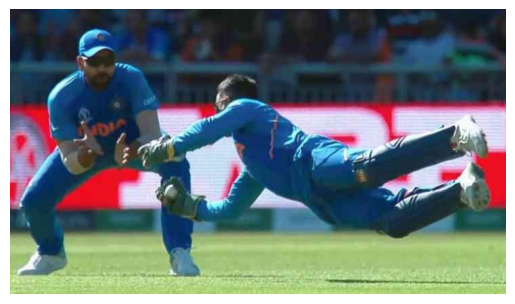

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2 
image=cv2.imread('dhoni_drive.jpeg')
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.axis('off')
plt.show()

In [2]:
pixel_vals = image.reshape((-1,3))
pixel_vals = np.float32(pixel_vals)
print(pixel_vals.shape)
print(pixel_vals[:5])

(305870, 3)
[[34. 32. 43.]
 [34. 32. 43.]
 [34. 32. 43.]
 [34. 32. 43.]
 [34. 32. 43.]]


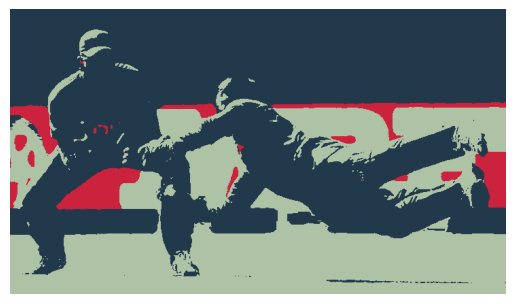

In [3]:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.85)
k=3 
retval, labels, centers = cv2.kmeans(pixel_vals, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers=np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((image.shape))
plt.imshow(segmented_image)
plt.axis('off')
plt.show()

unet 

In [7]:
import tensorflow as tf 
def encoder_block(input,num_filters):
    x=tf.keras.layers.Conv2D(num_filters,3,padding='valid')(input)
    x=tf.keras.layers.Activation('relu')(x)
    x=tf.keras.layers.Conv2D(num_filters,3,padding='valid')(x)
    x=tf.keras.layers.Activation('relu')(x)
    x=tf.keras.layers.Conv2D(num_filters,3,padding='valid')(x)
    x=tf.keras.layers.Activation('relu')(x)
    return x 

def decoder_block(input,skip_features,num_filters):
    x=tf.keras.layers.Conv2DTranspose(num_filters,(2,2),strides=2,padding='valid')(input)
    x=tf.keras.layers.Concatenate()([x,skip_features])
    x=tf.keras.layers.Conv2D(num_filters,3,padding='valid')(x)
    x=tf.keras.layers.Activation('relu')(x)
    x=tf.keras.layers.Conv2D(num_filters,3,padding='valid')(x)
    x=tf.keras.layers.Activation('relu')(x)
    return x

In [9]:
def unet_model(input_shape=(256,256,3),num_classes=1):
    inputs=tf.keras.layers.Input(input_shape)
    s1=encoder_block(inputs,64)
    s2=encoder_block(s1,128)
    s3=encoder_block(s2,256)
    s4=encoder_block(s3,512)
    #bottleneck
    b1=tf.keras.layers.Conv2D(1024,3,padding='valid')(s4)
    b1=tf.keras.layers.Activation('relu')(b1)
    b1=tf.keras.layers.Conv2D(1024,3,padding='valid')(b1)
    b1=tf.keras.layers.Activation('relu')(b1)

    #expansive path
    d1=decoder_block(b1,s4,512)
    d2=decoder_block(d1,s3,256)
    d3=decoder_block(d2,s2,128)
    d4=decoder_block(d3,s1,64)

    outputs=tf.keras.layers.Conv2D(num_classes,1,activation='sigmoid')(d4)
    model=tf.keras.Model(inputs,outputs,name='UNET')
    return model
if __name__=='__main__':
    model=unet_model(input_shape=(572,572,3),num_classes=2)
    model.summary()

ValueError: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 1088, 1088, 512), (None, 548, 548, 512)]